Pregnancies — количество беременностей.

Glucose — концентрация глюкозы в плазме через два часа при пероральном тесте на толерантность к глюкозе.

BloodPressure — диастолическое артериальное давление (мм рт. ст.).

SkinThickness — толщина кожной складки трицепса (мм).

Insulin — двухчасовой сывороточный инсулин (ме Ед/мл).

BMI — индекс массы тела (
весвкг

роствм).

DiabetesPedigreeFunction — функция родословной диабета (чем она выше, тем выше шанс наследственной заболеваемости).

Age — возраст.

Outcome — наличие диабета (0 — нет, 1 — да).

In [ ]:
import pandas as pd

diabetes = pd.read_csv('diabetes/diabetes_diabetes.csv')
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Gender
0,6,98,58,33,190,34.0,0.430,43,0,Female
1,2,112,75,32,0,35.7,0.148,21,0,Female
2,2,108,64,0,0,30.8,0.158,21,0,Female
3,8,107,80,0,0,24.6,0.856,34,0,Female
4,7,136,90,0,0,29.9,0.210,50,0,Female


In [ ]:
# Удолить дубликаты
diabetes = diabetes.drop_duplicates()

In [4]:
diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Gender
0,6,98,58,33,190,34.0,0.430,43,0,Female
1,2,112,75,32,0,35.7,0.148,21,0,Female
2,2,108,64,0,0,30.8,0.158,21,0,Female
3,8,107,80,0,0,24.6,0.856,34,0,Female
4,7,136,90,0,0,29.9,0.210,50,0,Female
...,...,...,...,...,...,...,...,...,...,...
763,5,139,64,35,140,28.6,0.411,26,0,Female
764,1,96,122,0,0,22.4,0.207,27,0,Female
765,10,101,86,37,0,45.6,1.136,38,1,Female
766,0,141,0,0,0,42.4,0.205,29,1,Female


In [5]:
# Удалить неинформативные признаки, парог - 0.95

#список неинформативных признаков
low_information_cols = [] 

#цикл по всем столбцам
for col in diabetes.columns:
    #наибольшая относительная частота в признаке
    top_freq = diabetes[col].value_counts(normalize=True).max()
    #доля уникальных значений от размера признака
    nunique_ratio = diabetes[col].nunique() / diabetes[col].count()
    # сравниваем наибольшую частоту с порогом
    if top_freq > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(top_freq*100, 2)}% одинаковых значений')
    # сравниваем долю уникальных значений с порогом
    if nunique_ratio > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(nunique_ratio*100, 2)}% уникальных значений')


# Удаляем неинформативные признаки
diabetes = diabetes.drop(columns=low_information_cols)
# Проверяем, что неинформативные признаки удалены
for col in low_information_cols:
    if col in diabetes.columns:
        print(f'Признак {col} не удален')
    else:
        print(f'Признак {col} успешно удален')

Gender: 100.0% одинаковых значений
Признак Gender успешно удален


In [ ]:
#  Замените все записи, равные 0, в столбцах Glucose, BloodPressure, SkinThickness, Insulin и BMI на символ пропуска. Его вы можете взять из библиотеки numpy: np.nan.

# Какая доля пропусков содержится в столбце Insulin? Ответ округлите до сотых.
import pandas as pd
import numpy as np
diabetes = pd.read_csv('diabetes.csv')
# Список столбцов, где нужно заменить 0 на NaN
cols_with_zero_nan = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Замена 0 на np.nan
diabetes[cols_with_zero_nan] = diabetes[cols_with_zero_nan].replace(0, np.nan)

# Расчёт доли пропусков в столбце 'Insulin'
missing_fraction = diabetes['Insulin'].isna().mean()

# Округление до сотых
missing_fraction_rounded = round(missing_fraction, 2)

print(f"Доля пропусков в 'Insulin': {missing_fraction_rounded}")

In [8]:
#  Замените все записи, равные 0, в столбцах Glucose, BloodPressure, SkinThickness, Insulin и BMI на символ пропуска. Его вы можете взять из библиотеки numpy: np.nan.

# Какая доля пропусков содержится в столбце Insulin? Ответ округлите до сотых.
import numpy as np

cols_with_zero_nan = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Замена 0 на np.nan
diabetes[cols_with_zero_nan] = diabetes[cols_with_zero_nan].replace(0, np.nan)

# Расчёт доли пусков в столбце 'Insulin'
missing_fraction = diabetes['Insulin'].isna().mean()

# Округление до сотых
missing_fraction_rounded = round(missing_fraction, 2)

print(f"Доля пропусков в 'Insulin': {missing_fraction_rounded}")

Доля пропусков в 'Insulin': 0.49


In [9]:
# Удалите из данных признаки, где число пропусков составляет более 30 %. Сколько признаков осталось в ваших данных 
# (с учетом удаленных неинформативных признаков в задании 8.2)?

threshold = 0.3  # Порог в 30%
# Вычисляем пороговое значение для удаления признаков
threshold_value = len(diabetes) * threshold
# Удаляем признаки с количеством пропусков больше порогового значения
diabetes = diabetes.dropna(thresh=len(diabetes) - threshold_value, axis=1)
# Выводим количество оставшихся признаков
remaining_features_count = len(diabetes.columns)
print(f"Количество признаков после удаления: {remaining_features_count}")
# Сохраните полученные данные в файл diabetes_clean.csv

Количество признаков после удаления: 8


In [11]:
# Удалите из данных только те строки, в которых содержится более двух пропусков одновременно. Чему равно результирующее число записей в таблице?

diabetes_clean = diabetes.dropna(thresh=len(diabetes.columns) - 2, axis=0)
# Выводим количество оставшихся записей
remaining_records_count = len(diabetes_clean)
print(f"Количество записей после удаления: {remaining_records_count}")

Количество записей после удаления: 761


In [12]:
# В оставшихся записях замените пропуски на медиану. Чему равно среднее значение в столбце SkinThickness? Ответ округлите до десятых. 
diabetes_clean.fillna(diabetes_clean.median(), inplace=True)
mean_skin_thickness = diabetes_clean['SkinThickness'].mean()
mean_skin_thickness_rounded = round(mean_skin_thickness, 1)
print(f"Среднее значение в столбце 'SkinThickness': {mean_skin_thickness_rounded}")

Среднее значение в столбце 'SkinThickness': 29.1


/tmp/ipykernel_37925/2583396571.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diabetes_clean.fillna(diabetes_clean.median(), inplace=True)


In [13]:
# Сколько выбросов найдёт классический метод межквартильного размаха в признаке SkinThickness?
Q1 = diabetes_clean['SkinThickness'].quantile(0.25)
Q3 = diabetes_clean['SkinThickness'].quantile(0.75)
IQR = Q3 - Q1
outliers = diabetes_clean[(diabetes_clean['SkinThickness'] < (Q1 - 1.5 * IQR)) | 
                          (diabetes_clean['SkinThickness'] > (Q3 + 1.5 * IQR))]
outliers_count = len(outliers)
print(f"Количество выбросов в 'SkinThickness': {outliers_count}")

Количество выбросов в 'SkinThickness': 87


In [14]:
# Сколько выбросов найдёт классический метод z-отклонения в признаке SkinThickness?
from scipy import stats
z_scores = stats.zscore(diabetes_clean['SkinThickness'])
outliers_z = diabetes_clean[(z_scores < -3) | (z_scores > 3)]
outliers_z_count = len(outliers_z)
print(f"Количество выбросов в 'SkinThickness' по методу z-отклонения: {outliers_z_count}")

Количество выбросов в 'SkinThickness' по методу z-отклонения: 4


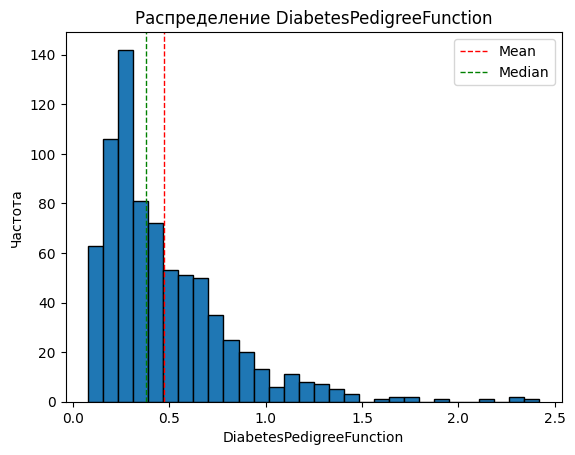

In [ ]:
# На приведённой гистограмме показано распределение признака DiabetesPedigreeFunction. Такой вид распределения очень похож на логнормальный, 
# и он заставляет задуматься о логарифмировании признака. Найдите сначала число выбросов в признаке DiabetesPedigreeFunction с помощью классического метода 
# межквартильного размаха.

# Затем найдите число выбросов в этом же признаке в логарифмическом масштабе (при логарифмировании единицу прибавлять не нужно!). 
# Какова разница между двумя этими числами (вычтите из первого второе)?


import matplotlib.pyplot as plt
# Гистограмма признака DiabetesPedigreeFunction
plt.hist(diabetes_clean['DiabetesPedigreeFunction'], bins=30, edgecolor='black')
plt.title('Распределение DiabetesPedigreeFunction')
plt.xlabel('DiabetesPedigreeFunction')
plt.ylabel('Частота')


# Линию на графике
plt.axvline(x=diabetes_clean['DiabetesPedigreeFunction'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(x=diabetes_clean['DiabetesPedigreeFunction'].median(), color='green', linestyle='dashed', linewidth=1, label='Median')
plt.legend()

plt.show()


In [21]:
def outliers_iqr_mod(data, feature, left=1.5, right=1.5, log_scale=False):
    if log_scale:
        x = np.log(data[feature])
    else:
        x= data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * left)
    upper_bound = quartile_3 + (iqr * right)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned


outliers, _ = outliers_iqr_mod(diabetes, 'DiabetesPedigreeFunction')
outliers_log, _ = outliers_iqr_mod(diabetes, 'DiabetesPedigreeFunction', log_scale=True)
print(outliers.shape[0] - outliers_log.shape[0])



29
